In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
'''-------------------PARAMETERS (edit here)-------------------'''
yaxis_range = (0, 5100)
plot_labels = ['HV Off', 'HV Low', 'HV High'] #must be parallel with filename_arr in the cell of the relevant VMM
plot_colors = ['blue', 'orange', 'green', 'red', 'purple'] #colors for the histograms, if plotting more than 5 datasets overlaid, add more colors

In [3]:
'''--------------------------FUNCTIONS--------------------------'''

def getVMMNumber(df):
    vmm_num_df = df['vmm']
    return int(vmm_num_df[0])

def getChannelAndSigmaAndError(df):
    df = df[(df[' fit sigma'] >= 0) & (df[' error sigma'] >= 0) & (df[' error sigma']/df[' fit sigma'] <= 0.05) & (df[' error sigma']/df[' fit sigma'] >= 0.00001)]
    channel = df['ch']
    sigma = df[' fit sigma']
    ErrorSigma = df[' error sigma']
    return channel, sigma, ErrorSigma

def plotSCurve(ax, df, vmm_num, color, label):
    channel, sigma, ErrorSigma = getChannelAndSigmaAndError(df)
    if vmm_num == 0 or vmm_num == 1:
        sigma = sigma / 9.0 * 6240
        ErrorSigma = ErrorSigma / 9.0 * 6240
    elif vmm_num == 2 or vmm_num == 3:
        sigma = sigma / 4.5 * 6240
        ErrorSigma = ErrorSigma / 4.5 * 6240
    
    line, caplines, barlinecols = ax.errorbar(channel, sigma, yerr=ErrorSigma, xerr=None, color=color,  fmt='o', ecolor='gray', capsize=4, label=label)
    return line, caplines, barlinecols

def ShowandSaveSCurve(filename_arr, yaxis_range=yaxis_range, plot_labels=plot_labels, plot_colors=plot_colors):
    fig, ax = plt.subplots()
    for i in range(0, len(filename_arr)):
        df = pd.read_csv(filename_arr[i])
        vmm_num = getVMMNumber(df)
        line, caplines, barlinecols = plotSCurve(ax, df, vmm_num, plot_colors[i], plot_labels[i])

    ax.set_xlabel("Channel Number")
    ax.set_ylabel("Noise [no. e]")
    ax.legend(loc='upper right')
    ax.set_ylim(yaxis_range)
    fig.savefig(f'plots/png/S_Curve_VMM{vmm_num}.png', bbox_inches="tight")
    fig.savefig(f'plots/pdf/S_Curve_VMM{vmm_num}.pdf', bbox_inches="tight")

Run the cell of the VMM you'd like to generate an S-Curve for. If new data is collected, update filename_arr.

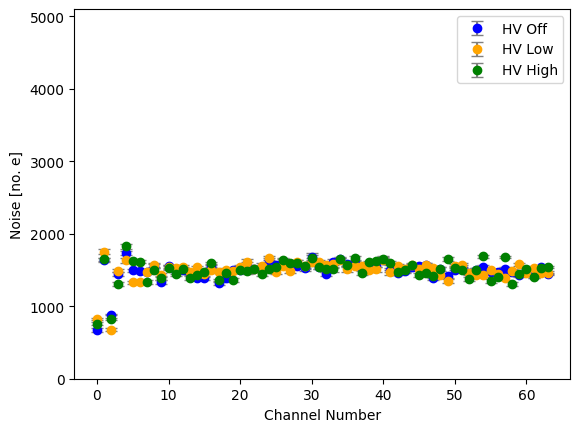

In [4]:
'''----------------------------VMM 0----------------------------'''

filename_arr = ['20251016-scurves/HV off/9mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_104118.csv', '20251016-scurves/HV low/9mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_113925.csv',
                '20251016-scurves/HV high/9mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_121646.csv']

ShowandSaveSCurve(filename_arr, yaxis_range, plot_labels, plot_colors)

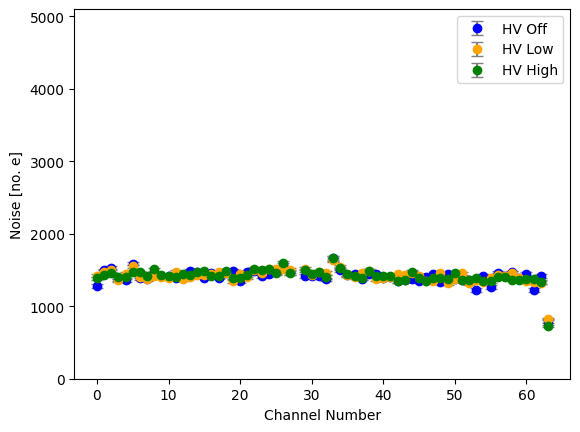

In [5]:
'''----------------------------VMM 1----------------------------'''

filename_arr = ['20251016-scurves/HV off/9mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_105505.csv', '20251016-scurves/HV low/9mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_115250.csv',
                '20251016-scurves/HV high/9mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_123001.csv']

ShowandSaveSCurve(filename_arr, yaxis_range, plot_labels, plot_colors)

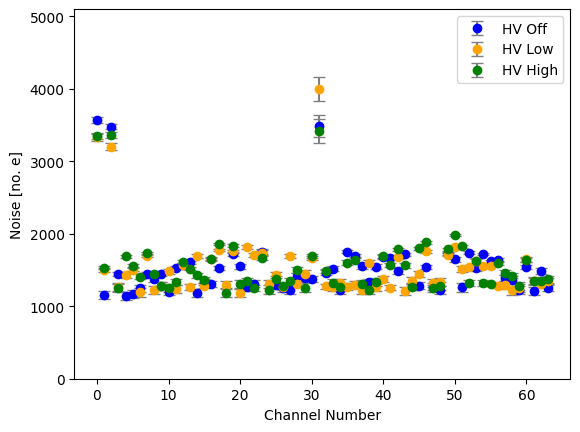

In [6]:
'''----------------------------VMM 2----------------------------'''

filename_arr = ['20251016-scurves/HV off/4.5mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_104826.csv', '20251016-scurves/HV low/4.5mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_114609.csv',
                '20251016-scurves/HV high/4.5mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_122331.csv']

ShowandSaveSCurve(filename_arr, yaxis_range, plot_labels, plot_colors)

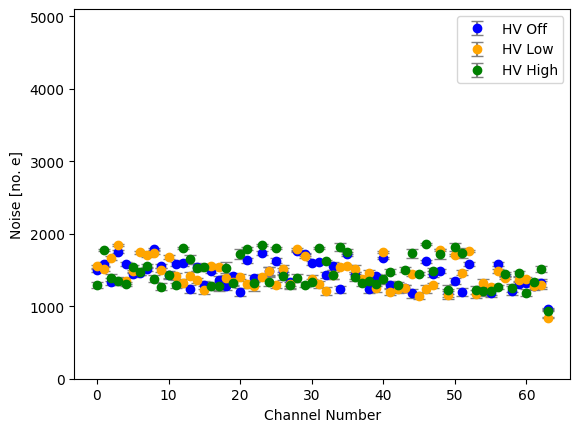

In [7]:
'''----------------------------VMM 3----------------------------'''

filename_arr = ['20251016-scurves/HV off/4.5mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_110204.csv', '20251016-scurves/HV low/4.5mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_115950.csv',
                '20251016-scurves/HV high/4.5mVfC_200ns_60ns_negative/Fit_S-curvescanned_threshold_123725.csv']

ShowandSaveSCurve(filename_arr, yaxis_range, plot_labels, plot_colors)